<a href="https://colab.research.google.com/github/ShitoshnaSingh/Assignment01/blob/main/2332945_ShitoshnaSingh(Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/FinalPortfolio/Regression/

/content/drive/MyDrive/FinalPortfolio/Regression


In [3]:
# reading csv file and importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
df = pd.read_csv('global air pollution dataset.csv')
df.info()
df.head(500)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
495,Brazil,Delmiro Gouveia,25,Good,0,Good,9,Good,1,Good,25,Good
496,Uruguay,Delta Del Tigre,38,Good,1,Good,19,Good,2,Good,38,Good
497,India,Delvada,158,Unhealthy,0,Good,25,Good,0,Good,158,Unhealthy
498,Russian Federation,Desnogorsk,34,Good,1,Good,34,Good,0,Good,10,Good


In [4]:
rows = df.shape[0]
columns = df.shape[1]
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 23463
Number of columns: 12


In [5]:
columns = df.dtypes
print(columns)

Country               object
City                  object
AQI Value              int64
AQI Category          object
CO AQI Value           int64
CO AQI Category       object
Ozone AQI Value        int64
Ozone AQI Category    object
NO2 AQI Value          int64
NO2 AQI Category      object
PM2.5 AQI Value        int64
PM2.5 AQI Category    object
dtype: object


In [6]:
# Checking for missing values
missing_values = df.isnull().sum()

# Checking for duplicate rows
duplicate_rows = df.duplicated().sum()

# Checking basic statistics for numerical columns
numerical_summary = df.describe()

# Checking unique values in categorical columns
categorical_unique_values = df.select_dtypes(include=['object']).nunique()

missing_values, duplicate_rows, numerical_summary, categorical_unique_values


(Country               427
 City                    1
 AQI Value               0
 AQI Category            0
 CO AQI Value            0
 CO AQI Category         0
 Ozone AQI Value         0
 Ozone AQI Category      0
 NO2 AQI Value           0
 NO2 AQI Category        0
 PM2.5 AQI Value         0
 PM2.5 AQI Category      0
 dtype: int64,
 0,
           AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  \
 count  23463.000000  23463.000000     23463.000000   23463.000000   
 mean      72.010868      1.368367        35.193709       3.063334   
 std       56.055220      1.832064        28.098723       5.254108   
 min        6.000000      0.000000         0.000000       0.000000   
 25%       39.000000      1.000000        21.000000       0.000000   
 50%       55.000000      1.000000        31.000000       1.000000   
 75%       79.000000      1.000000        40.000000       4.000000   
 max      500.000000    133.000000       235.000000      91.000000   
 
        PM2.5 AQI Value  

In [7]:
import pandas as pd

# Function to check missing values denoted by '-200' in a dataset
def check_missing_values(file_path):
    # Reading the dataset from the given file path
    df = pd.read_csv(file_path)

    # Counting missing values where "-200" is used as an indicator
    missing_values_custom = (df == -200).sum()

    # Counting total rows with at least one "-200" value
    rows_with_missing = (df == -200).any(axis=1).sum()

    return missing_values_custom, rows_with_missing

# Example usage: replace with the actual file path
file_path = 'global air pollution dataset.csv'

missing_values, rows_with_missing = check_missing_values(file_path)

print("Missing values per column where '-200' is used as an indicator:")
print(missing_values)
print("\nTotal rows with at least one '-200' value:")
print(rows_with_missing)

Missing values per column where '-200' is used as an indicator:
Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64

Total rows with at least one '-200' value:
0


In [8]:
# Manage missing values

import pandas as pd

# Load the cleaned dataset with missing values represented as -200

# Replacing -200 with NaN to make it easier to handle missing values
df.replace(-200, pd.NA, inplace=True)

# Handling missing values in numerical columns (mean imputation)
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

# Handling missing values in categorical columns (mode imputation)
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

# Save the dataset after handling missing values

# Check for any remaining missing values
missing_values = df.isnull().sum()
print("Remaining missing values:", missing_values)


Remaining missing values: Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64


In [9]:
# Outliers check

import pandas as pd

# Load the dataset

# Select numerical columns for outlier detection
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate IQR for each numerical column
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers: any value outside the bounds
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)

# Count the number of outliers in each column
outliers_count = outliers.sum()

# Display the number of outliers in each column
print(outliers_count)


AQI Value          2935
CO AQI Value       8596
Ozone AQI Value    1513
NO2 AQI Value      1681
PM2.5 AQI Value    2641
dtype: int64


In [10]:
# Handle outliers

import pandas as pd

# Load the dataset

# Select numerical columns for outlier detection
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate IQR for each numerical column
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Handle outliers by replacing them with lower or upper bound
df[numerical_columns] = df[numerical_columns].apply(
    lambda x: x.clip(lower=lower_bound[x.name], upper=upper_bound[x.name])
)

# Checking if the outliers were handled
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)
outliers_count = outliers.sum()

# Display the number of outliers in each column
print(outliers_count)


AQI Value          0
CO AQI Value       0
Ozone AQI Value    0
NO2 AQI Value      0
PM2.5 AQI Value    0
dtype: int64


In [11]:
# Display if any outlier exists

# Load the dataset

# Select numerical columns for outlier detection
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate IQR for each numerical column
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Check for outliers (True if outlier, False otherwise)
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)

# Count the number of outliers in each column
outliers_count = outliers.sum()

# Check if there are any outliers
outliers_check = outliers_count > 0
# Save the cleaned dataframe to a new CSV file
df.to_csv('global air pollution dataset outliers removed.csv', index=False)
print("Cleaned data saved to separate file")
# Display the number of outliers per column and if any outliers exist
print("Number of outliers in each column:")
print(outliers_count)

Cleaned data saved to separate file
Number of outliers in each column:
AQI Value          0
CO AQI Value       0
Ozone AQI Value    0
NO2 AQI Value      0
PM2.5 AQI Value    0
dtype: int64


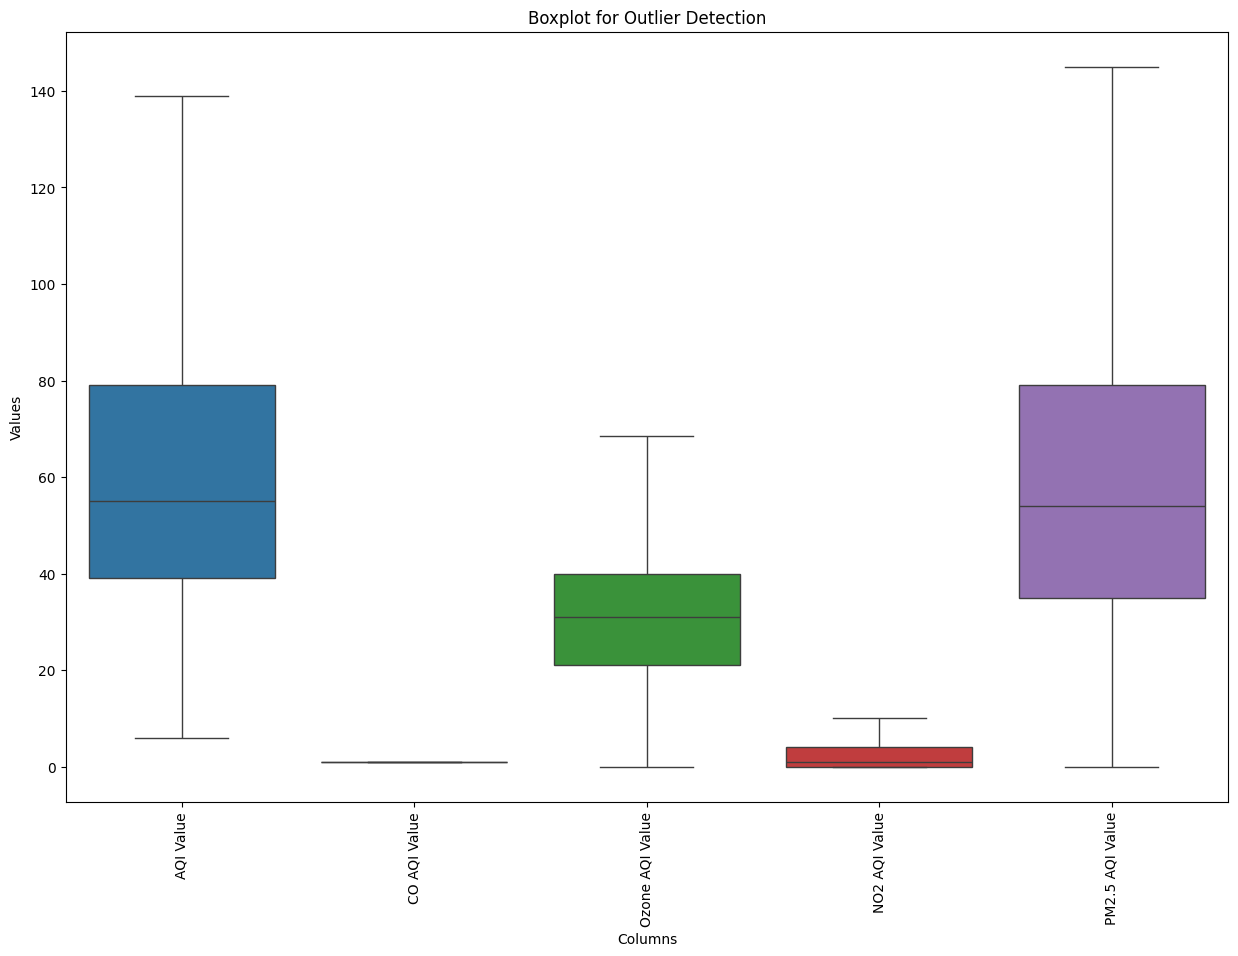

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Plot boxplot for each numerical column in the dataset
sns.boxplot(data=df)

# Set title and labels for clarity
plt.title("Boxplot for Outlier Detection")
plt.xlabel("Columns")
plt.ylabel("Values")

# Display the plot
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.show()

<Figure size 1500x1000 with 0 Axes>

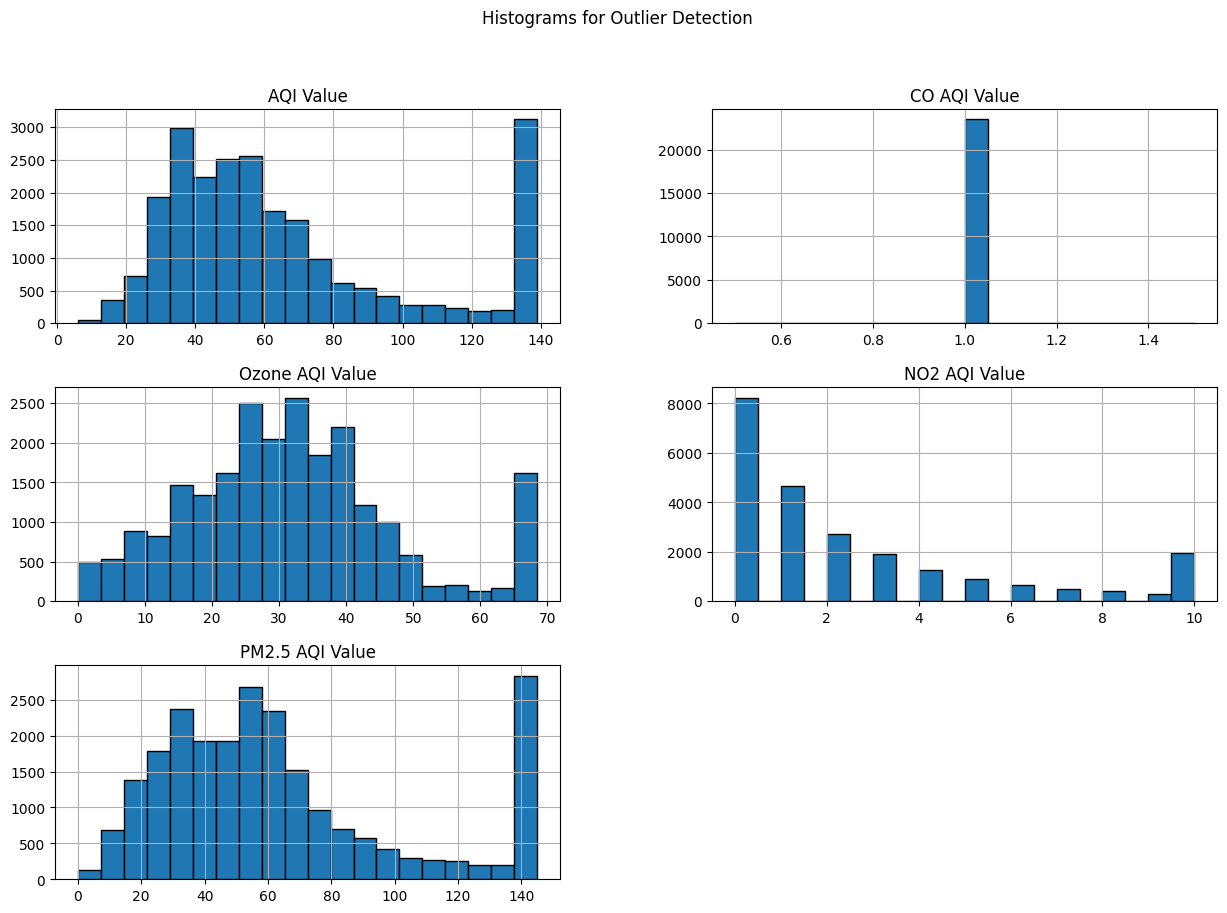

In [13]:
# Histogram

import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Plot histograms for each numerical column in the dataset
df.hist(bins=20, figsize=(15, 10), edgecolor='black')

# Set title and labels for clarity
plt.suptitle("Histograms for Outlier Detection")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Display the plot
plt.show()

In [14]:
# Print column names to check if 'Date' and 'Time' exist
print(df.columns)

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')


In [15]:
# "Primary Model 1" trained by linear regression imported from sklearn library

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the cleaned dataframe 'df' is already loaded earlier

# Drop non-numeric columns (e.g., Country, City, etc.)
df_numeric = df.drop(columns=['Country', 'City', 'AQI Category', 'CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category'])  # Drop 'Country', City', 'AQI Category', 'CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category' columns

# Define the feature (independent) variables and the target variable
# Assuming the target variable is 'AQI Value', replace with the actual column name
X = df_numeric.drop(columns=['AQI Value'])  # Independent variables (drop the target column)
y = df_numeric['AQI Value']  # Target variable

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 40.57948755684975
R-squared (R²): 0.9680911034643295


In [16]:
# "Primary Model 2" trained by random forest imported from sklearn library

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned data
df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Drop non-numeric columns if necessary (e.g., Country, City columns)
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Define features (X) and target (y)
X = df_numeric.drop(columns=['AQI Value'])  # Independent variables
y = df_numeric['AQI Value']  # Target variable

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)


Mean Squared Error (MSE): 7.760690801361241
R-squared (R²): 0.9938975306309858



- Mean Squared Error (MSE):**
  - **Linear Regression:**  (lower is better)
  - **Random Forest:**  (slightly higher)

- R-Squared (R²):**
  - **Linear Regression:** 96% (explains 96% of variance)
  - **Random Forest:** 99% (better performance, explains 99% of variance)

### Key Points:
- **Linear Regression:** Simpler, works well for linear relationships.
- **Random Forest:** Better for complex, non-linear relationships; handles feature interactions better.

### Conclusion:
- **Random Forest** outperforms **Linear Regression** in terms of accuracy (higher R² and marginally better MSE).
- **Linear Regression** is simpler but less accurate for this dataset.

In [17]:
# Linear regression model built from scratch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Assuming the cleaned dataframe 'df' is already loaded earlier

# Drop non-numeric columns (e.g., Country, City, etc.)
df = df.select_dtypes(include=['float64', 'int64'])

# Define the feature (independent) variables and the target variable
X = df.drop('AQI Value', axis=1).values  # Independent variables (drop the target column)
y = df['AQI Value'].values  # Target variable

# Add a column of ones to the features matrix for the intercept term (bias)
X = np.c_[np.ones(X.shape[0]), X]

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression from scratch

# Step 1: Compute the coefficients using the normal equation (using pseudo-inverse)
def linear_regression(X, y):
    # Use np.linalg.pinv for better numerical stability
    beta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)
    return beta

# Step 2: Train the model
beta = linear_regression(X_train, y_train)

# Step 3: Make predictions
y_pred = X_test.dot(beta)

# Step 4: Evaluate the model's performance

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# R-squared (R²)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 40.57948755684965
R-squared (R²): 0.9680911034643296


In [18]:
# (Ridge regression) hyperparameter tuning for linear regression buit using sklearn library Model 1

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned dataset
# df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Drop non-numeric columns
df_numeric = df.drop(columns=['Country', 'City', 'AQI Category', 'CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category'], errors='ignore')

# Define features (X) and target (y)
X = df_numeric.drop(columns=['AQI Value'])  # Independent variables
y = df_numeric['AQI Value']  # Target variable

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Ridge Regression model
ridge = Ridge()

# Define hyperparameter grid (values of alpha)
param_grid = {'alpha': np.logspace(-3, 3, 10)}

# Perform Grid Search with 5-fold Cross-Validation
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_alpha = grid_search.best_params_['alpha']
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate the optimized model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print(f"Best Alpha: {best_alpha}")
print(f"Optimized Ridge Regression - Mean Squared Error (MSE): {mse}")
print(f"Optimized Ridge Regression - R-squared (R²): {r2}")


Best Alpha: 215.44346900318823
Optimized Ridge Regression - Mean Squared Error (MSE): 40.57949698276176
Optimized Ridge Regression - R-squared (R²): 0.9680910960524456


Selected features: Index(['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value'], dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=4. There will be no feature selection and all features will be kept.
  warnings.warn(


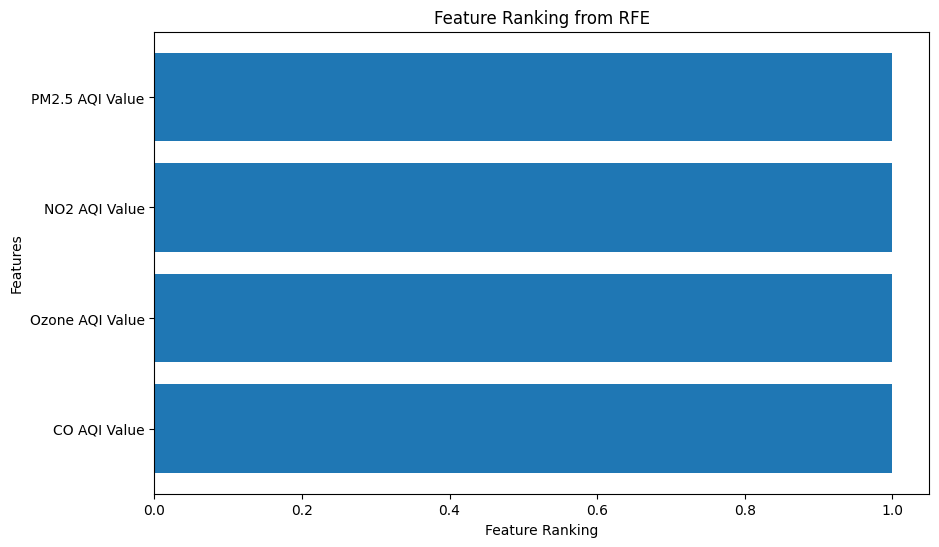

In [19]:
# Feature selection for linear regression model using Recursive Feature Elimination (RFE)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# Load cleaned data
# df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Drop non-numeric columns (Country, City)
df = df.select_dtypes(include=['float64', 'int64'])

# Define features (X) and target (y)
X = df.drop('AQI Value', axis=1)  # Independent variables
y = df['AQI Value']  # Target variable

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the linear regression model
lr_model = LinearRegression()

# Apply RFE for feature selection
selector = RFE(lr_model, n_features_to_select=5)  # Select top 5 features
selector = selector.fit(X_train, y_train)

# Get the selected features
selected_features = X.columns[selector.support_]

# Update X_train and X_test to include only the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Show the selected features
print("Selected features:", selected_features)

# Plot feature ranking
plt.figure(figsize=(10, 6))
plt.barh(X.columns, selector.ranking_)
plt.xlabel('Feature Ranking')
plt.ylabel('Features')
plt.title('Feature Ranking from RFE')
plt.show()



In [20]:
# Retraining of linear regression model using feature selection & hyperparameters

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load cleaned dataset
df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Drop non-numeric columns (Country, City)
df = df.select_dtypes(include=['float64', 'int64'])

# Define features (X) and target (y)
X = df[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]  # Only selected features
y = df['AQI Value']  # Target variable

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Ridge Regression model with the best alpha
ridge = Ridge(alpha=0.46415888336127775)

# Train the model
ridge.fit(X_train, y_train)

# Make predictions
y_pred = ridge.predict(X_test)

# Evaluate the optimized model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Optimized Ridge Regression with Feature Selection - Mean Squared Error (MSE): {mse}")
print(f"Optimized Ridge Regression with Feature Selection - R-squared (R²): {r2}")


Optimized Ridge Regression with Feature Selection - Mean Squared Error (MSE): 40.579487575469535
Optimized Ridge Regression with Feature Selection - R-squared (R²): 0.9680911034496882


In [21]:
# Hyperparameter tuning for Model 2 (Random forest)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the model
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameters to tune
param_dist = {
    'n_estimators': np.arange(50, 300, 50),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Perform RandomizedSearchCV (faster than GridSearchCV)
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=20,  # Number of different combinations to try
    cv=5,       # 5-fold cross-validation
    n_jobs=-1,  # Use all available CPUs
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=42
)

# Fit the model
random_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = random_search.best_params_
best_score = random_search.best_score_

print(f"Best Hyperparameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': True}
Best Cross-Validation Score: -7.154410257331719


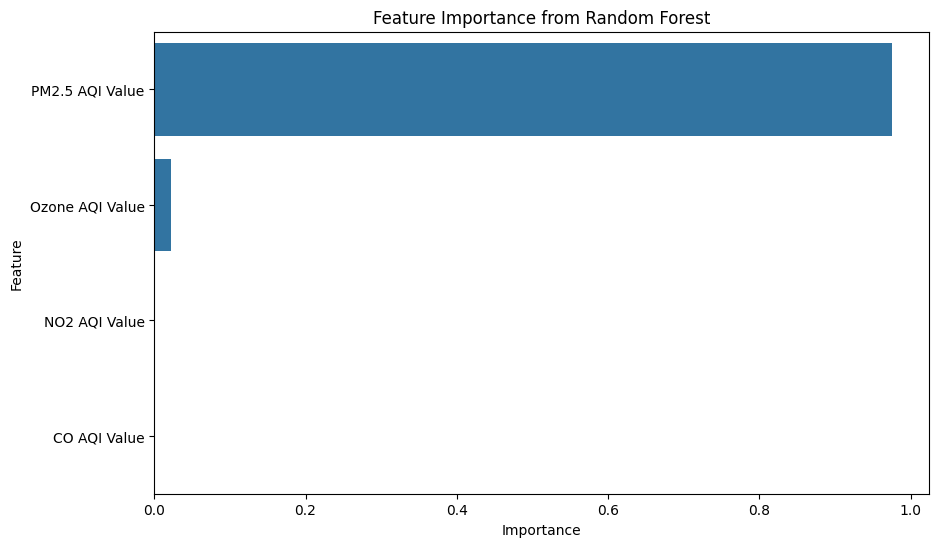

Selected Features: ['PM2.5 AQI Value' 'Ozone AQI Value' 'NO2 AQI Value' 'CO AQI Value']


In [22]:
# Feature selection for Model 2 (Random forest)

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the cleaned dataframe 'df' is already loaded earlier

# Drop non-numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Define the feature (independent) variables and the target variable
X = df_numeric.drop(columns=['AQI Value'])  # Independent variables
y = df_numeric['AQI Value']  # Target variable

# Train Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importance
importances = rf.feature_importances_

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance from Random Forest")
plt.show()

# Select top 5 features (for example, change this based on the result)
selected_features = feature_importance_df['Feature'].head(5).values
print(f"Selected Features: {selected_features}")


Selected features: Index(['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value'], dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=5 > n_features=4. There will be no feature selection and all features will be kept.
  warnings.warn(


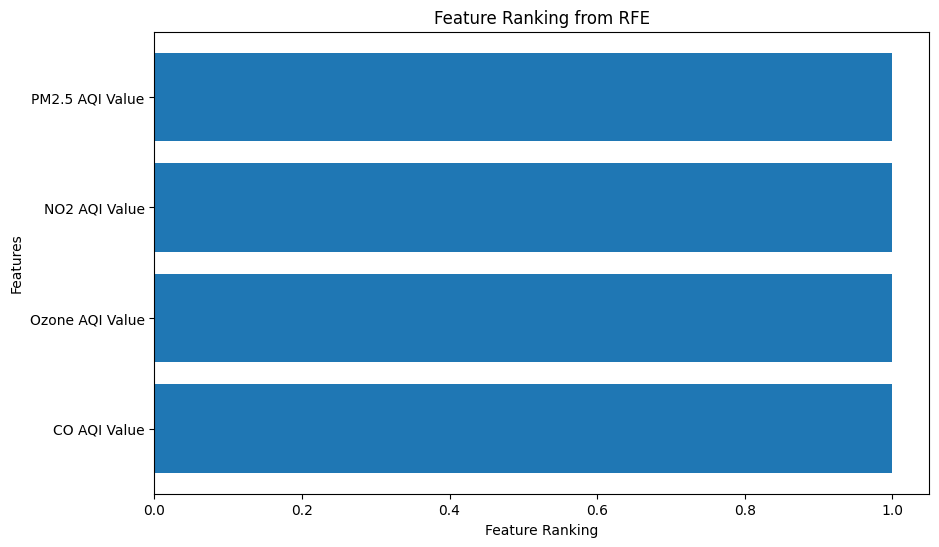

Random Forest Performance with Feature Selection:
Mean Squared Error (MSE): 7.98033152973542
R-squared (R²): 0.9937248203850299


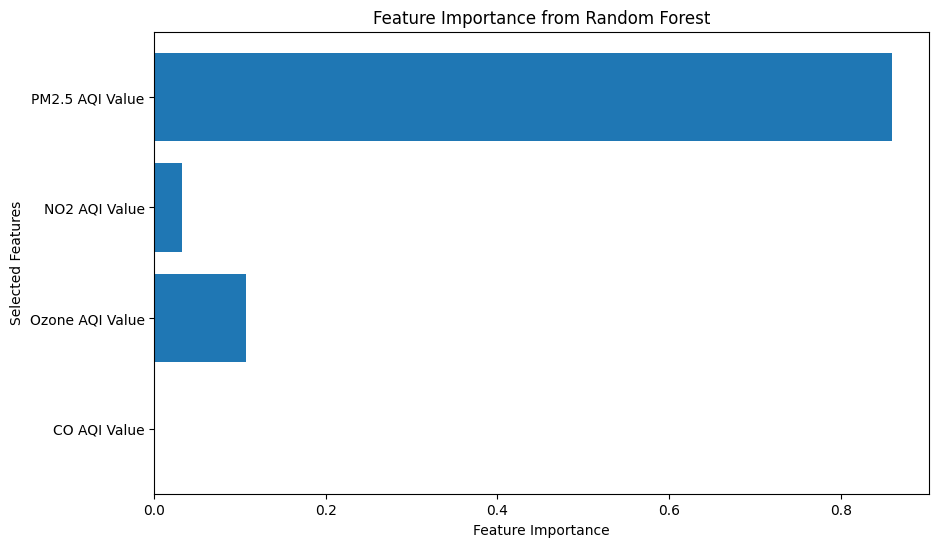

In [23]:
# Model retraining using feature selection and hyperparameters for Random forest Model 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Load cleaned data
df = pd.read_csv('global air pollution dataset outliers removed.csv')

# Drop non-numeric columns (Date, Time)
df = df.select_dtypes(include=['float64', 'int64'])

# Define features (X) and target (y)
X = df.drop('AQI Value', axis=1)  # Independent variables
y = df['AQI Value']  # Target variable

# --- Feature Selection with RFE ---
lr_model = LinearRegression()

# Apply RFE for feature selection
selector = RFE(lr_model, n_features_to_select=5)  # Select top 5 features
selector = selector.fit(X, y)

# Get the selected features
selected_features = X.columns[selector.support_]

# Show the selected features
print("Selected features:", selected_features)

# --- Plot Feature Ranking ---
plt.figure(figsize=(10, 6))
plt.barh(X.columns, selector.ranking_)
plt.xlabel('Feature Ranking')
plt.ylabel('Features')
plt.title('Feature Ranking from RFE')
plt.show()

# --- Train Random Forest with optimal hyperparameters ---
# Use only the selected features for training
X_selected = X[selected_features]

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Example optimal hyperparameters from the previous tuning (you can modify based on earlier results)
rf_optimal = RandomForestRegressor(n_estimators=50,  # Example optimal value from hyperparameter tuning
                                   min_samples_split=2,  # Example optimal value
                                   min_samples_leaf=2,   # Example optimal value
                                   max_features='log2',  # Example optimal value
                                   max_depth=50,         # Example optimal value
                                   bootstrap=False,      # Example optimal value
                                   random_state=42)

# Train the Random Forest model
rf_optimal.fit(X_train, y_train)
y_pred_rf = rf_optimal.predict(X_test)

# Evaluate Random Forest performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Display Random Forest performance
print("Random Forest Performance with Feature Selection:")
print("Mean Squared Error (MSE):", mse_rf)
print("R-squared (R²):", r2_rf)

# --- Plot Feature Importance from Random Forest ---
plt.figure(figsize=(10, 6))
plt.barh(selected_features, rf_optimal.feature_importances_)
plt.xlabel('Feature Importance')
plt.ylabel('Selected Features')
plt.title('Feature Importance from Random Forest')
plt.show()


In [24]:
# # Print accuracies for all models

# # Linear Regression from scratch
# print("Accuracy of Linear Regression model from scratch (R-squared):", r2_lr)

# # Ridge Regression (Linear Regression with Regularization)
# print("Accuracy of Ridge Regression model (R-squared):", r2_ridge)

# # Random Forest (with hyperparameters)
# print("Accuracy of Random Forest model (R-squared):", r2_rf)

# # Linear Regression (from sklearn with feature selection and hyperparameters)
# print("Accuracy of Optimized Linear Regression model (R-squared):", r2)

# # Random Forest (with feature selection and optimal hyperparameters)
# print("Accuracy of Optimized Random Forest model (R-squared):", r2_rf)

Raw linear regression Model 1:

Trained using library
Mean Squared Error (MSE): 40.57948755684975
R-squared (R²): 0.9680911034643295


Raw linear regression Model 2:

Trained using library
Mean Squared Error (MSE): 7.760690801361241
R-squared (R²): 0.9938975306309858
Random forest performed better justified.

Linear regression model built from scratch:

Mean Squared Error (MSE): 40.57948755684965
R-squared (R²): 0.9680911034643296




Using hyperparameter and feature selection retrained model for linear regression:


Optimized Ridge Regression with Feature Selection - Mean Squared Error (MSE): 40.579487575469535
Optimized Ridge Regression with Feature Selection - R-squared (R²): 0.9680911034496882


Using hyperparameter and feature selection retrained model for Random forest
Random Forest Performance with Feature Selection:


Mean Squared Error (MSE): 7.98033152973542
R-squared (R²): 0.9937248203850299